In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

**Load Data**

In [2]:
df = pd.read_csv("/content/15_9-23.csv")
df.describe()

,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,CALI,RSHA,RMED,RDEP,RHOB,GR,...,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE
count,11063.000000,11063.000000,1.106300e+04,11063.000000,11063.000000,0.0,11009.000000,11063.000000,11009.000000,11063.000000,...,11027.000000,10424.000000,11063.000000,11063.000000,0.0,0.0,11024.000000,0.0,11063.000000,11059.00000
mean,2367.135122,433919.013649,6.459992e+06,-2341.932173,12.043442,NaN,1.462600,1.422385,2.345301,85.533311,...,111.272184,263.320978,0.246235,0.051607,NaN,NaN,96.055188,NaN,65580.197776,1.11303
std,490.393818,6.748644,7.108452e+00,490.282226,1.320629,NaN,1.514766,1.434520,0.166377,46.606858,...,76.485602,83.595229,0.414689,0.027060,NaN,NaN,61.692089,NaN,9780.543173,0.36667
min,1518.280000,433906.750000,6.459977e+06,-3187.130371,8.263517,NaN,0.167987,0.180957,1.257591,11.680315,...,6.427914,115.207130,-5.500000,-0.217746,NaN,NaN,8.523534,NaN,30000.000000,1.00000
25%,1938.636000,433914.687500,6.459986e+06,-2766.083252,12.270368,NaN,0.622986,0.607275,2.216724,54.470312,...,51.774763,181.473476,0.064966,0.034956,NaN,NaN,46.425519,NaN,65000.000000,1.00000
50%,2371.000000,433918.687500,6.459994e+06,-2345.820801,12.412058,NaN,0.756025,0.738392,2.325151,90.380005,...,90.004684,292.924637,0.192399,0.048182,NaN,NaN,81.606464,NaN,65000.000000,1.00000
75%,2791.356000,433923.562500,6.459999e+06,-1913.512024,12.635700,NaN,1.609376,1.579940,2.497720,110.643826,...,150.792122,338.326797,0.398251,0.065997,NaN,NaN,129.740578,NaN,65030.000000,1.00000
max,3212.624000,433933.281250,6.460000e+06,-1493.241821,19.163353,NaN,23.936893,17.415550,3.104144,411.181122,...,694.254578,378.333893,6.455294,0.207971,NaN,NaN,439.485748,NaN,99000.000000,3.00000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11063 entries, 0 to 11062
Data columns (total 29 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   WELL                               11063 non-null  object 
 1   DEPTH_MD                           11063 non-null  float64
 2   X_LOC                              11063 non-null  float64
 3   Y_LOC                              11063 non-null  float64
 4   Z_LOC                              11063 non-null  float64
 5   GROUP                              11063 non-null  object 
 6   FORMATION                          11063 non-null  object 
 7   CALI                               11063 non-null  float64
 8   RSHA                               0 non-null      float64
 9   RMED                               11009 non-null  float64
 10  RDEP                               11063 non-null  float64
 11  RHOB                               11009 non-null  flo

**To check the null values**

In [10]:
df1 = (df.isnull().sum() / len(df))*100
df1[df1>0]

,0
RSHA,100.000000
RMED,0.488114
RHOB,0.488114
SGR,100.000000
NPHI,0.235018
PEF,2.042846
DTC,1.102775
SP,100.000000
ROP,0.325409
DTS,5.776010


**Drop the column where null values > 75% and also unwanted columns**

In [11]:
df1=df.drop(columns =["RSHA","SGR","SP","MUDWEIGHT","RMIC","RXO","FORCE_2020_LITHOFACIES_CONFIDENCE","FORCE_2020_LITHOFACIES_LITHOLOGY"])

In [12]:
df2 = (df1.isnull().sum() / len(df1))*100
df2[df2>0]

,0
RMED,0.488114
RHOB,0.488114
NPHI,0.235018
PEF,2.042846
DTC,1.102775
ROP,0.325409
DTS,5.776010
ROPA,0.352526


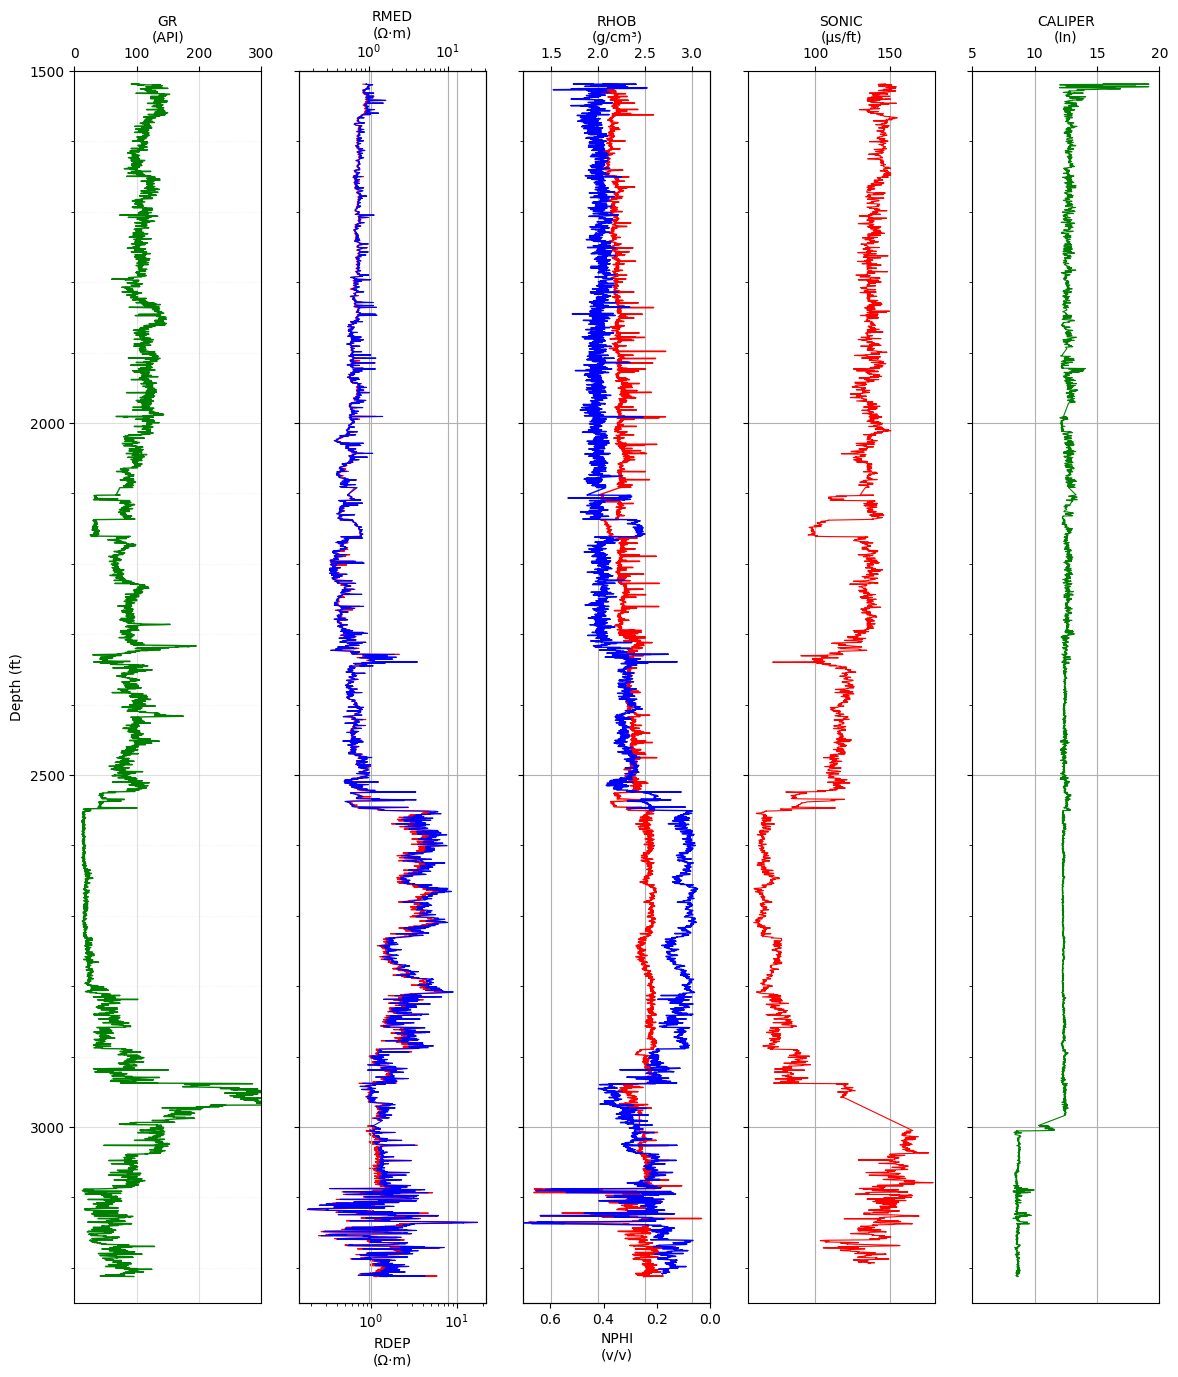

In [24]:
fig, ax = plt.subplots(
    nrows=1,
    ncols=5,
    figsize=(14, 16),
    sharey=True
)

# =========================
# TRACK 1 - GAMMA RAY
# =========================
ax[0].plot(df1["GR"], df1["DEPTH_MD"], color='green', linewidth=1)
ax[0].set_xlabel("GR\n(API)")
ax[0].set_ylabel("Depth (ft)")
ax[0].set_xlim(0, 300)
ax[0].invert_yaxis()
ax[0].set_ylim(3250, 1500)                            # ← your depth window
ax[0].yaxis.set_major_locator(MultipleLocator(500))   # ← tick density
ax[0].yaxis.set_minor_locator(MultipleLocator(100))
ax[0].grid(which='major', alpha=0.4)
ax[0].grid(which='minor', alpha=0.15, linestyle=':')
ax[0].xaxis.set_ticks_position('top')
ax[0].xaxis.set_label_position('top')

# =========================
# TRACK 2 - RESISTIVITY
# =========================
ax_rmed = ax[1]
ax_rdep = ax_rmed.twiny()
#RMED
ax_rmed.plot(df1["RMED"], df1["DEPTH_MD"], color='red', linewidth=0.8)
ax_rmed.set_xlabel("RMED\n(Ω·m)")
ax_rmed.set_xscale("log")
ax_rmed.tick_params(axis='x')
ax_rmed.xaxis.set_ticks_position('top')
ax_rmed.xaxis.set_label_position('top')
ax_rmed.grid()
#RDEP
ax_rdep.plot(df1["RDEP"], df1["DEPTH_MD"], color='blue', linewidth=0.8)
ax_rdep.set_xlabel("RDEP\n(Ω·m)")
ax_rdep.tick_params(axis='x')
ax_rdep.set_xscale("log")
ax_rdep.grid()
ax_rdep.xaxis.set_ticks_position('bottom')
ax_rdep.xaxis.set_label_position('bottom')

# =========================
# TRACK 3 - DENSITY / NEUTRON
# =========================
ax_rhob = ax[2]                          # primary axis → RHOB
ax_nphi = ax_rhob.twiny()                  # secondary axis → NPHI (shares y)

# RHOB (primary, bottom spine → moved to top)
ax_rhob.plot(df1["RHOB"], df1["DEPTH_MD"], color="red", linewidth=1, label="RHOB")
ax_rhob.set_xlim(1.2, 3.2)
ax_rhob.set_xlabel("RHOB\n(g/cm³)")
ax_rhob.tick_params(axis='x')
ax_rhob.xaxis.set_ticks_position('top')
ax_rhob.xaxis.set_label_position('top')
ax_rhob.grid()

# NPHI (secondary, inverted scale — petrophysical convention)
ax_nphi.plot(df1["NPHI"], df1["DEPTH_MD"], color="blue", linewidth=1, label="NPHI")
ax_nphi.set_xlim(0.7,0)             # ← inverted: high on left, low on right
ax_nphi.set_xlabel("NPHI\n(v/v)")
ax_nphi.tick_params(axis='x')
ax_nphi.xaxis.set_ticks_position('bottom')   # NPHI axis at bottom to avoid clash
ax_nphi.xaxis.set_label_position('bottom')

# =========================
# TRACK 4 - SONIC
# =========================

ax[3].plot(df1["DTC"], df1["DEPTH_MD"], color='red', linewidth=.8)
ax[3].set_xlim(55,180)
ax[3].set_xlabel("SONIC\n(µs/ft)")
ax[3].grid()
ax[3].xaxis.set_ticks_position('top')
ax[3].xaxis.set_label_position('top')

# =========================
# TRACK 5 - CALIPER
# =========================

ax[4].plot(df1["CALI"], df1["DEPTH_MD"], color='green', linewidth=.8)
ax[4].set_xlim(5,20)
ax[4].set_xlabel("CALIPER\n(In)")
ax[4].grid()
ax[4].xaxis.set_ticks_position('top')
ax[4].xaxis.set_label_position('top')